In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/glove6b100dtxt/glove.6B.100d.txt
/kaggle/input/glove42b300dtxt/glove.42B.300d.txt
/kaggle/input/glove6b200d/glove.6B.200d.txt
/kaggle/input/enterpretdata/train - train.csv
/kaggle/input/enterpretdata/test - test.csv


In [2]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
import re
import torch
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cufflinks as cf
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataset import random_split
from tqdm import tqdm, tqdm_notebook
from functools import partial
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/opt/conda/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning:

The Shapely GEOS version (3.9.1-CAPI-1.14.2) is incompatible with the GEOS version PyGEOS was compiled with (3.10.0-CAPI-1.16.0). Conversions between both will be slow.



In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def stopword(text):
    return [token for token in text if token not in stop_words]

def tokenize(text, reverse=False):
    text = re.sub(r'[^\w\s]','',text)
    text = re.sub(r'[0-9]+', '', text)
    text = text.lower()
    tokens = wordpunct_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [lemmatizer.lemmatize(token,'v') for token in tokens]
    if reverse:
        tokens = tokens[::-1]
    return tokens
def break_sent(text,aspect):
    x_l, _, x_r = [s.lower().strip() for s in text.partition(aspect)]
    return x_l,x_r

In [5]:
def pad_sequence(sequences, sequence_len, padding_idx=0):
    
    return sequences + [padding_idx]*(sequence_len-len(sequences))

In [6]:
class Data(Dataset):
    def __init__(self, data_path,train=True):
        super(Data, self).__init__()
        df = pd.read_csv(data_path)

        df['x_l'],df['x_r'] = "",""

        for i in range(len(df)):
            df['x_l'][i], df['x_r'][i] = break_sent(df['text'][i], df['aspect'][i])

        stop_words = set(stopwords.words('english'))
        lemmatizer = WordNetLemmatizer()
        df['tokens'] = df['text'].apply(tokenize)
        df['tokens'] = df['tokens'].apply(stopword)

        #build vocab
        vocab = sorted(set(token for doc in list(df.tokens) for token in doc))
        self.token2idx = {token: idx for idx, token in enumerate(vocab)}
        # padding
        self.token2idx['<PAD>'] = max(self.token2idx.values()) + 1
        self.idx2token = {idx: token for idx, token in enumerate(vocab)}

        #sequence
        df['indexed_tokens'] = df.tokens.apply(lambda doc: [self.token2idx[token] for token in doc])
        
        
        df['left_indices_aspect_indices'] = (df['x_l'] + " " + df['aspect']).apply(tokenize)
        df['left_indices_aspect_indices'] = df['left_indices_aspect_indices'].apply(stopword)
        df['left_indices_aspect_indices'] = df.left_indices_aspect_indices.apply(
            lambda doc: [self.token2idx[token] for token in doc if token in self.token2idx])
        for i in range(len(df['left_indices_aspect_indices'])):
            df['left_indices_aspect_indices'][i] = pad_sequence(df['left_indices_aspect_indices'][i], sequence_len=200)

        df['right_indices_aspect_indices'] = (df['aspect'] + " " + df['x_r']).apply(tokenize,reverse=True)
        df['right_indices_aspect_indices'] = df['right_indices_aspect_indices'].apply(stopword)
        df['right_indices_aspect_indices'] = df.right_indices_aspect_indices.apply(
            lambda doc: [self.token2idx[token] for token in doc if token in self.token2idx])
        for i in range(len(df['right_indices_aspect_indices'])):
            df['right_indices_aspect_indices'][i] = pad_sequence(df['right_indices_aspect_indices'][i],sequence_len=200)

        df['aspect_indices'] = df['aspect'].apply(tokenize)
        df['aspect_indices'] = df.aspect_indices.apply(
            lambda doc: [self.token2idx[token] for token in doc if token in self.token2idx])
        for i in range(len(df['aspect_indices'])):
            df['aspect_indices'][i] = pad_sequence(df['aspect_indices'][i], sequence_len=200)
        
        self.riai_len = max(len(sequence) for sequence in df['right_indices_aspect_indices'])
        aspect_len = np.sum(df['aspect_indices'] != 0)


        text_len = np.sum(df['indexed_tokens'] != 0)

        self.left_indices_aspect_indices = df.left_indices_aspect_indices.tolist()
        self.right_indices_aspect_indices = df.right_indices_aspect_indices.tolist()
        self.aspect_indices = df.aspect_indices.tolist()
        self.target = df.label.tolist()

    def __getitem__(self, idx):
        return (

            self.left_indices_aspect_indices[idx],
            self.right_indices_aspect_indices[idx],
            self.aspect_indices[idx],
            self.target[idx],
            
        )

    def __len__(self):
        return len(self.target)

In [7]:
train_path = "/kaggle/input/enterpretdata/train - train.csv"
dataset = Data(train_path)

In [8]:
len(dataset.aspect_indices[0]),len(dataset.right_indices_aspect_indices[0])

(200, 200)

In [9]:
def split_train_valid(dataset) :
    valid = int(len(dataset) * 0.3)
    train = len(dataset) - valid
    return random_split(dataset, lengths=[train,valid])
train_dataset,valid_dataset = split_train_valid(dataset)
len(train_dataset),len(valid_dataset)

(2800, 1200)

In [10]:
BATCH_SIZE = 140
def collate(batch):
    left_indices_aspect_indices =[item[0] for item in batch ]
    left_indices_aspect_indices = torch.tensor(left_indices_aspect_indices)
    right_indices_aspect_indices = [item[1] for item in batch ]
    right_indices_aspect_indices = torch.tensor(right_indices_aspect_indices)
    aspect_indices = [item[2] for item in batch ]
    aspect_indices = torch.tensor(aspect_indices)
    target = torch.LongTensor([item[3] for item in batch])
    return left_indices_aspect_indices, right_indices_aspect_indices, aspect_indices, target
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, collate_fn=collate)

In [11]:
for left_indices_aspect_indices, right_indices_aspect_indices, aspect_indices, target in train_dataloader:
    print(left_indices_aspect_indices)

tensor([[1347, 1315, 3113,  ...,    0,    0,    0],
        [1444, 1962, 3375,  ...,    0,    0,    0],
        [ 784,  199, 2645,  ...,    0,    0,    0],
        ...,
        [ 169,    0,    0,  ...,    0,    0,    0],
        [ 435, 1540, 2036,  ...,    0,    0,    0],
        [3472, 2258,    0,  ...,    0,    0,    0]])
tensor([[3375,  548, 2069,  ...,    0,    0,    0],
        [1405,  112, 2791,  ...,    0,    0,    0],
        [ 212, 2275, 2545,  ...,    0,    0,    0],
        ...,
        [1802, 2080, 1816,  ...,    0,    0,    0],
        [ 810, 3475, 3537,  ...,    0,    0,    0],
        [ 169, 1724, 1799,  ...,    0,    0,    0]])
tensor([[1999, 2369,    0,  ...,    0,    0,    0],
        [2840, 2778,  865,  ...,    0,    0,    0],
        [1271,  269, 1999,  ...,    0,    0,    0],
        ...,
        [1931, 2084, 3576,  ...,    0,    0,    0],
        [3427, 1347, 2755,  ...,    0,    0,    0],
        [2367, 2805,    0,  ...,    0,    0,    0]])
tensor([[ 411, 2328, 1

In [12]:
def read_glove_vector(glove_vec):
    with open(glove_vec, 'r', encoding='UTF-8') as f:
        words = set()
        word_to_vec_map = {}
        for line in f:
            w_line = line.split()
            curr_word = w_line[0]
            word_to_vec_map[curr_word] = np.array(w_line[1:], dtype=np.float64)
    return word_to_vec_map
word_to_vec_map = read_glove_vector('../input/glove6b200d/glove.6B.200d.txt')

In [13]:
embedding_matrix= np.zeros((len(dataset.token2idx), 200))
embeddings_path = "../input/embed-path-file/embedding_path.txt"
for token,idx in dataset.token2idx.items():
    embed_vector = word_to_vec_map.get(token)
    if embed_vector is not None:
        embedding_matrix[idx:] = embed_vector
embedding_matrix 

array([[ 0.030697,  0.74523 , -0.047813, ...,  0.13697 ,  0.16943 ,
         0.29801 ],
       [ 0.030697,  0.74523 , -0.047813, ...,  0.13697 ,  0.16943 ,
         0.29801 ],
       [ 0.030697,  0.74523 , -0.047813, ...,  0.13697 ,  0.16943 ,
         0.29801 ],
       ...,
       [ 0.30629 , -0.038208,  0.36634 , ..., -0.52205 , -0.27231 ,
         0.12473 ],
       [ 0.30629 , -0.038208,  0.36634 , ..., -0.52205 , -0.27231 ,
         0.12473 ],
       [ 0.30629 , -0.038208,  0.36634 , ..., -0.52205 , -0.27231 ,
         0.12473 ]])

In [14]:
class DynamicLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers=1, bidirectional=False, dropout=0.2 ):
        super(DynamicLSTM, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        #self.batch_size = batch_size
        self.n_layers = n_layers
        self.bidirectinal = bidirectional
        self.dropout = dropout

        self.lstm = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True, bias=True, bidirectional=bidirectional)

    def forward(self,x,x_len):

        #sequence -> sort -> pack and pad -> Use lstm -> unsort -> unsequence

        #sorting
        x_len = x_len.clamp(min=1,max=30)
        x_sort_index = torch.sort(x_len,descending=True)[1].long()
        x_unsort_index = torch.sort(x_sort_index)[1].long()
        x_len = x_len[x_sort_index]
        x = x[x_sort_index]

        #packing
        x_emb_p = pack_padded_sequence(x,x_len,batch_first=True)

        # LSTM layer
        out_pack,(ht,ct) = self.lstm(x_emb_p, None)

        #unsort h
        ht = torch.transpose(ht,0,1)[x_unsort_index]
        ht = torch.transpose(ht,0,1)

        #unpack
        out = pad_packed_sequence(out_pack, batch_first=True)
        out = out[0]
        out = out[x_unsort_index]

        #unsort c:
        ct = torch.transpose(ct,0,1)[x_unsort_index]
        ct = torch.transpose(ct,0,1)

        return  out,(ht,ct)

class LSTM(nn.Module):
    def __init__(self, embed_matrix, embed_dim, hidden_dim, output_dim):
        super(LSTM, self).__init__()
        self.embed_matrix = embed_matrix
        self.output_dim = output_dim
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim

        self.embedding  = nn.Embedding.from_pretrained(torch.tensor(self.embed_matrix, dtype=torch.float))
        self.lstm_left  = DynamicLSTM(self.embed_dim*2, self.hidden_dim, n_layers=1)
        self.lstm_right = DynamicLSTM(self.embed_dim*2, self.hidden_dim, n_layers=1)
        self.fc = nn.Linear(self.hidden_dim*2, self.output_dim)

    def forward(self,inputs):
        x_l,x_r,target = inputs[0],inputs[1],inputs[2]

        x_l_len,x_r_len = torch.sum(x_l!=0, dim=-1), torch.sum(x_r!=0, dim=-1)
        target_len = torch.sum(target != 0, dim=-1, dtype=torch.float)[:, None, None]

        #embedding
        x_l,x_r,target = self.embedding(x_l),self.embedding(x_r), self.embedding(target)

        # for w word of length n. {w1,w2,..,wl} is preceding word and {wr, wr+1,..., wn} and {wl+1,...,wr-l} ar target words

        #v-target : average of target words

        v_target = torch.div(target.sum(dim=1,keepdim=True),target_len)

        # concanate the word embedding and target vector

        x_l = torch.cat((x_l, torch.cat(([v_target] * x_l.shape[1]), 1)),1)
        x_r = torch.cat((x_r, torch.cat(([v_target] * x_r.shape[1]), 1)),1)

        # out

        _, (h_n_l, _) = self.lstm_left(x_l, x_l_len)
        _, (h_n_r, _) = self.lstm_right(x_r, x_r_len)
        h_n = torch.cat((h_n_l[0],h_n_r[0]),dim=-1)
        out = self.fc(h_n)
        out = torch.sigmoid(out)
        return out

In [15]:
class TD_LSTM(nn.Module):
    def __init__(self,  embed_matrix, embed_dim, hidden_dim, output_dim):
        super(TD_LSTM, self).__init__()
        
        self.embed_matrix = embed_matrix
        self.output_dim = output_dim
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim

        self.embedding  = nn.Embedding.from_pretrained(torch.tensor(self.embed_matrix, dtype=torch.float))
        self.lstm_left  = DynamicLSTM(self.embed_dim, self.hidden_dim, n_layers=1)
        self.lstm_right = DynamicLSTM(self.embed_dim, self.hidden_dim, n_layers=1)
        self.fc = nn.Linear(self.hidden_dim*2, self.output_dim)

    def forward(self, inputs):
        x_l, x_r = inputs[0], inputs[1]
        x_l_len, x_r_len = torch.sum(x_l != 0, dim=-1), torch.sum(x_r != 0, dim=-1)
        x_l, x_r = self.embed(x_l), self.embed(x_r)
        _, (h_n_l, _) = self.lstm_left(x_l, x_l_len)
        _, (h_n_r, _) = self.lstm_right(x_r, x_r_len)
        h_n = torch.cat((h_n_l[0], h_n_r[0]), dim=-1)
        out = self.fc(h_n)
        return out

In [16]:
def train_epoch(model, optimizer, scheduler, train_loader):
    model.train()
    n_correct = total_loss = total = 0
    for left_indices_aspect_indices, right_indices_aspect_indices, aspect_indices, target in train_loader:
        target = target.to(device)
        
        optimizer.zero_grad()
        
        inputs = [ left_indices_aspect_indices, right_indices_aspect_indices, aspect_indices] 
        
        #forward pass
        output = model(inputs)
        
        #Calculate loss 
        loss = criterion(output, target)
        
        #Perform gradient descent. Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        #Taking a step
        optimizer.step()
        scheduler.step()
        
        n_correct += (torch.argmax(output, -1) == target).sum().item()
        total_loss += loss.item()
        total += len(target)

    return (total_loss / total),((n_correct/total)*100.0)
        

In [17]:
def validate_epoch(model, valid_loader):
    model.eval()
    n_correct = total_loss = total = 0
    with torch.no_grad():
        for left_indices_aspect_indices, right_indices_aspect_indices, aspect_indices, target in valid_loader:
            target = target.to(device)

            inputs = [ left_indices_aspect_indices, right_indices_aspect_indices, aspect_indices] 

            #forward pass
            output = model(inputs)

            #Calculate loss 
            loss = criterion(output, target)

            n_correct += (torch.argmax(output, -1) == target).sum().item()
            total_loss += loss.item()
            total += len(target)

    return (total_loss / total),((n_correct/total)*100.0)
        

In [18]:
vocab_size = len(dataset.token2idx)
n_layer = 1
embed_dim = 100
hidden_dim = 50
output_dim = 3
bidirectional = True
dropout= 0.2
max_epochs = 1000
learning_rate = 2e-5


lstm_model = LSTM(embed_matrix=embedding_matrix, embed_dim=embed_dim, hidden_dim=hidden_dim, output_dim=output_dim).to(device)

In [19]:
td_lstm = TD_LSTM(embed_matrix=embedding_matrix, embed_dim=embed_dim, hidden_dim=hidden_dim, output_dim=output_dim).to(device)

In [20]:
td_lstm

TD_LSTM(
  (embedding): Embedding(3601, 200)
  (lstm_left): DynamicLSTM(
    (lstm): LSTM(100, 50, batch_first=True)
  )
  (lstm_right): DynamicLSTM(
    (lstm): LSTM(100, 50, batch_first=True)
  )
  (fc): Linear(in_features=100, out_features=3, bias=True)
)

In [21]:
lstm_model

LSTM(
  (embedding): Embedding(3601, 200)
  (lstm_left): DynamicLSTM(
    (lstm): LSTM(200, 50, batch_first=True)
  )
  (lstm_right): DynamicLSTM(
    (lstm): LSTM(200, 50, batch_first=True)
  )
  (fc): Linear(in_features=100, out_features=3, bias=True)
)

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, lstm_model.parameters()),
    lr=learning_rate,
)
scheduler = CosineAnnealingLR(optimizer, 1)

In [23]:
epochs = 0
lstm_train_losses, lstm_valid_losses = [], []
for _ in range(max_epochs):
    lstm_train_loss,train_acc = train_epoch(lstm_model, optimizer, scheduler, train_dataloader)
    lstm_valid_loss,valid_acc = validate_epoch(lstm_model, valid_dataloader)
    
    tqdm.write(
        f'epoch #{epochs + 1:3d}\ttrain_loss: {lstm_train_loss:.2e}'
        f'\ttrain_acc: {train_acc:.2f}'
        f'\tvalid_loss: {lstm_valid_loss:.2e}'
        f'\tvalid_acc: {valid_acc:.2f}\n',
    )
    
    # Early stopping if the current valid_loss is greater than the last three valid losses
    if len(lstm_valid_losses) > 2 and all(lstm_valid_loss >= loss
                                     for loss in lstm_valid_losses[-3:]):
        print('Stopping early')
        break
    
    lstm_train_losses.append(lstm_train_loss)
    lstm_valid_losses.append(lstm_valid_loss)
    
    
    epochs += 1

epoch #  1	train_loss: 7.84e-03	train_acc: 34.29	valid_loss: 8.23e-03	valid_acc: 35.00

epoch #  2	train_loss: 7.84e-03	train_acc: 34.75	valid_loss: 8.23e-03	valid_acc: 35.58

epoch #  3	train_loss: 7.84e-03	train_acc: 35.11	valid_loss: 8.23e-03	valid_acc: 35.92

epoch #  4	train_loss: 7.83e-03	train_acc: 35.93	valid_loss: 8.22e-03	valid_acc: 36.58

epoch #  5	train_loss: 7.83e-03	train_acc: 36.18	valid_loss: 8.22e-03	valid_acc: 37.00

epoch #  6	train_loss: 7.83e-03	train_acc: 36.71	valid_loss: 8.22e-03	valid_acc: 37.00

epoch #  7	train_loss: 7.82e-03	train_acc: 37.61	valid_loss: 8.21e-03	valid_acc: 37.42

epoch #  8	train_loss: 7.82e-03	train_acc: 37.82	valid_loss: 8.21e-03	valid_acc: 37.58

epoch #  9	train_loss: 7.82e-03	train_acc: 38.61	valid_loss: 8.21e-03	valid_acc: 38.42

epoch # 10	train_loss: 7.81e-03	train_acc: 39.61	valid_loss: 8.20e-03	valid_acc: 39.58

epoch # 11	train_loss: 7.81e-03	train_acc: 40.57	valid_loss: 8.20e-03	valid_acc: 40.17

epoch # 12	train_loss: 7.81e-03	

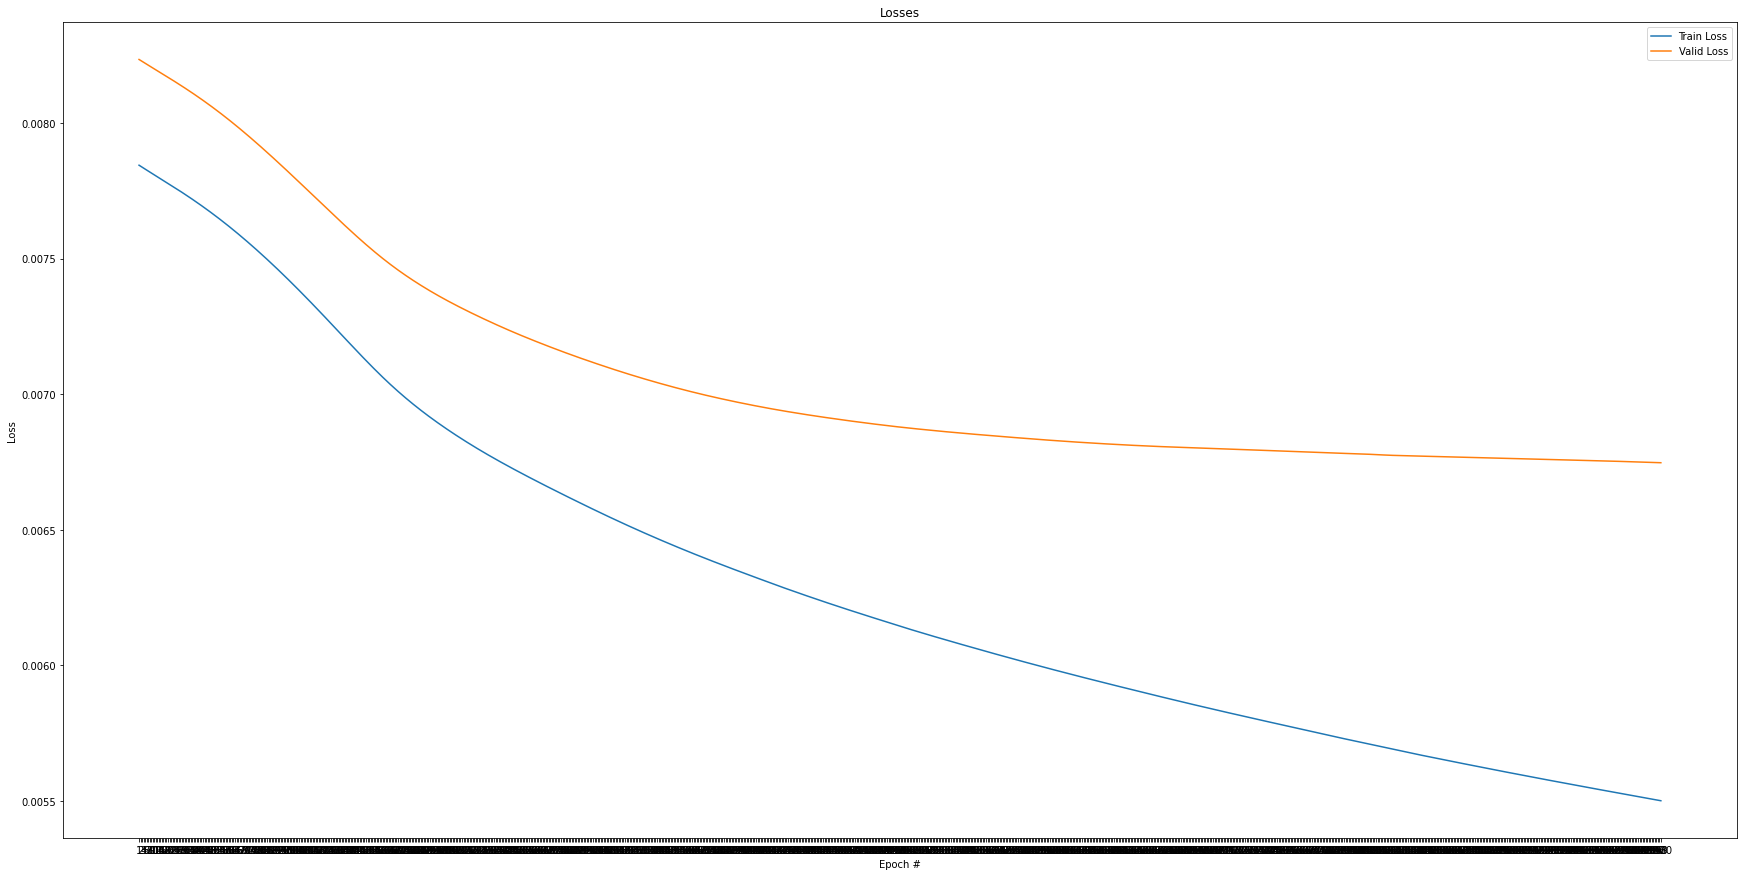

In [24]:
epoch_ticks = range(1, epochs + 1)
plt.figure(figsize=(30,15))
plt.plot(epoch_ticks, lstm_train_losses)
plt.plot(epoch_ticks, lstm_valid_losses)
plt.legend(['Train Loss', 'Valid Loss'])
plt.title('Losses') 
plt.xlabel('Epoch #')
plt.ylabel('Loss')
plt.xticks(epoch_ticks)
plt.show()

In [25]:
def indexed_token(tokens):
    indexed_tokens = []
    for token in tokens:
        if token in dataset.token2idx:
            indexed_tokens.append(dataset.token2idx[token])
    return indexed_tokens

In [26]:
class Test_Data(Dataset):
    def __init__(self, data_path):
        super(Test_Data, self).__init__()
        

        test_data = pd.read_csv(data_path)
        test_data['tokens'] = test_data['text'].apply(tokenize)
        test_data['tokens'] = test_data['tokens'].apply(stopword)
        test_data['indexed_tokens'] = test_data.tokens.apply(indexed_token)

        test_data['x_l'],test_data['x_r'] = "",""

        for i in range(len(test_data)):
            test_data['x_l'][i], test_data['x_r'][i] = break_sent(test_data['text'][i], test_data['aspect'][i])

        test_data['left_indices_aspect_indices'] = (test_data['x_l'] + " " + test_data['aspect']).apply(tokenize)
        test_data['left_indices_aspect_indices'] = test_data['left_indices_aspect_indices'].apply(stopword)
        test_data['left_indices_aspect_indices'] = test_data.left_indices_aspect_indices.apply(
                lambda doc: [dataset.token2idx[token] for token in doc if token in dataset.token2idx])
        for i in range(len(test_data['left_indices_aspect_indices'])):
            test_data['left_indices_aspect_indices'][i] = pad_sequence(test_data['left_indices_aspect_indices'][i], sequence_len=200)

        test_data['right_indices_aspect_indices'] = (test_data['aspect'] + " " + test_data['x_r']).apply(tokenize)
        test_data['right_indices_aspect_indices'] = test_data['right_indices_aspect_indices'].apply(stopword)
        test_data['right_indices_aspect_indices'] = test_data.right_indices_aspect_indices.apply(
                lambda doc: [dataset.token2idx[token] for token in doc if token in dataset.token2idx])
        for i in range(len(test_data['right_indices_aspect_indices'])):
            test_data['right_indices_aspect_indices'][i] = pad_sequence(test_data['right_indices_aspect_indices'][i], sequence_len=200)


        test_data['aspect_indices'] = test_data['aspect'].apply(tokenize)
        test_data['aspect_indices'] = test_data.aspect_indices.apply(
                lambda doc: [dataset.token2idx[token] for token in doc if token in dataset.token2idx])
        for i in range(len(test_data['aspect_indices'])):
            test_data['aspect_indices'][i] = pad_sequence(test_data['aspect_indices'][i], sequence_len=200)

        self.left_indices_aspect_indices = test_data.left_indices_aspect_indices.tolist()
        self.right_indices_aspect_indices = test_data.right_indices_aspect_indices.tolist()
        self.aspect_indices = test_data.aspect_indices.tolist()
        

    def __getitem__(self, idx):
        return (

            self.left_indices_aspect_indices[idx],
            self.right_indices_aspect_indices[idx],
            self.aspect_indices[idx],
            
            
        )

    def __len__(self):
        return len(self.aspect_indices)

In [27]:
test_path = "../input/enterpretdata/test - test.csv"
test_data = Test_Data(test_path)

In [28]:
def collate(batch):
    left_indices_aspect_indices =[item[0] for item in batch ]
    left_indices_aspect_indices = torch.tensor(left_indices_aspect_indices)
    right_indices_aspect_indices = [item[1] for item in batch ]
    right_indices_aspect_indices = torch.tensor(right_indices_aspect_indices)
    aspect_indices = [item[2] for item in batch ]
    aspect_indices = torch.tensor(aspect_indices)
    return left_indices_aspect_indices, right_indices_aspect_indices, aspect_indices
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, collate_fn=collate)

In [29]:
test_df = pd.read_csv("../input/enterpretdata/test - test.csv")
test_df

,text,aspect
0,improve your customer service and product avai...,Customer service
1,"functionality is great, almost as in desktop v...",mobile version
2,but it keeps starting from zoomed in and then ...,zoomed
3,hey marilyn thanks for your answer the soc2 ty...,Security
4,@delanovc @zoom @airtable @notionhq @calendly ...,apple
...,...,...
995,in a database where i have multiple views enab...,views
996,the mere act of opening the @notionhq tab make...,opening
997,i have shared it to web now and added the link...,web
998,why the members who regularly buy milk has to ...,service charge.


In [30]:
test_df['label'] = ""
lstm_model.eval()
sentiment = {0:"Negative", 1:"Neutal", 2:"Positive"}
test_labels = []
with torch.no_grad():
    for idx, (left_indices_aspect_indices, right_indices_aspect_indices, aspect_indices) in enumerate(test_dataloader):
            #target = target.item()
        inputs = [ left_indices_aspect_indices, right_indices_aspect_indices, aspect_indices]
        pred = lstm_model(inputs)
        
        pred = pred.detach().cpu().numpy()
        
        predictions = np.argmax(pred,axis=1)
        print(predictions)    #predicted = sentiment[predictions]
        
        test_labels.append(predictions)
        

[0 2 1 1 0 2 0 1 2 2 2 0 0 1 0 2 0 1 0 1 0 0 0 1 1 2 2 0 2 1 0 0 2 1 0 0 1
 0 0 1 0 0 1 1 2 2 1 1 0 1 1 2 0 1 2 0 0 1 1 0 1 1 1 1 2 0 0 2 1 1 2 1 0 1
 0 2 1 0 0 2 0 1 1 1 2 0 2 0 0 0 0 1 1 1 0 2 0 1 1 0 0 0 1 2 1 0 1 0 1 0 1
 0 1 0 0 1 0 0 2 0 1 0 0 0 1 2 2 0 2 1 0 0 0 2 2 0 0 2 0 0]
[1 2 0 2 0 2 1 1 0 2 1 0 0 2 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 2 0 1 0 0 0 2 1
 1 0 1 2 0 1 1 0 1 2 1 1 0 2 1 0 0 0 0 2 2 0 1 0 2 2 1 0 0 1 0 1 2 1 2 1 1
 1 2 0 0 2 2 2 0 0 2 1 1 1 1 0 0 1 0 1 0 0 2 0 2 1 1 0 2 1 1 0 2 2 1 1 1 1
 0 0 1 0 0 2 2 0 1 2 1 2 0 0 2 1 1 1 2 0 0 0 1 0 1 0 1 1 0]
[1 0 1 2 0 0 2 0 1 1 0 0 2 2 0 0 0 0 2 0 0 2 0 2 2 0 0 0 1 1 0 0 0 0 0 1 2
 1 0 2 0 0 1 0 1 2 2 0 1 2 0 1 1 1 0 1 2 2 1 0 0 1 1 1 2 1 1 2 2 0 0 2 1 0
 1 1 0 1 1 0 1 0 0 1 0 0 2 1 0 0 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1 0 0 2 1
 0 0 1 0 2 0 0 1 0 2 0 1 0 2 2 1 1 0 0 1 0 0 1 2 0 0 0 0 2]
[2 2 0 1 2 0 0 0 2 0 0 0 1 0 2 1 2 1 0 1 0 2 1 1 1 0 0 2 0 2 2 2 0 2 1 1 0
 0 0 0 0 0 0 1 0 0 0 2 0 1 1 0 0 0 0 2 2 0 1 0 0 1 2 0 1 2 2 2 1 1 2 1

In [31]:
test_labels

[array([0, 2, 1, 1, 0, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 2, 0, 1, 0, 1, 0, 0,
        0, 1, 1, 2, 2, 0, 2, 1, 0, 0, 2, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
        2, 2, 1, 1, 0, 1, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 1, 1, 1, 1, 2, 0,
        0, 2, 1, 1, 2, 1, 0, 1, 0, 2, 1, 0, 0, 2, 0, 1, 1, 1, 2, 0, 2, 0,
        0, 0, 0, 1, 1, 1, 0, 2, 0, 1, 1, 0, 0, 0, 1, 2, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 0, 1, 0, 0, 2, 0, 1, 0, 0, 0, 1, 2, 2, 0, 2, 1, 0, 0,
        0, 2, 2, 0, 0, 2, 0, 0]),
 array([1, 2, 0, 2, 0, 2, 1, 1, 0, 2, 1, 0, 0, 2, 1, 0, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 0, 0, 0, 2, 1, 1, 0, 1, 2, 0, 1, 1,
        0, 1, 2, 1, 1, 0, 2, 1, 0, 0, 0, 0, 2, 2, 0, 1, 0, 2, 2, 1, 0, 0,
        1, 0, 1, 2, 1, 2, 1, 1, 1, 2, 0, 0, 2, 2, 2, 0, 0, 2, 1, 1, 1, 1,
        0, 0, 1, 0, 1, 0, 0, 2, 0, 2, 1, 1, 0, 2, 1, 1, 0, 2, 2, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 2, 2, 0, 1, 2, 1, 2, 0, 0, 2, 1, 1, 1, 2, 0, 0,
        0, 1, 0, 1, 0, 1, 1, 0]),
 array([1, 0, 1, 2, 0, 0, 2, 0, 1, 1, 0, 0, 

In [32]:
label = []
for i in range(len(test_labels)):
    for j in range(len(test_labels[i])):
        label.append(test_labels[i][j])
for i in range(len(test_df)):
    test_df['label'][i] = label[i]

In [33]:
i = 500
test_df['text'][i],test_df['aspect'][i], test_df['label'][i]

('best productivity app I have ever used, but mobile version is slow and laggy even on mid-range hardware.',
 'app',
 2)

In [34]:
test_df

,text,aspect,label
0,improve your customer service and product avai...,Customer service,0
1,"functionality is great, almost as in desktop v...",mobile version,2
2,but it keeps starting from zoomed in and then ...,zoomed,1
3,hey marilyn thanks for your answer the soc2 ty...,Security,1
4,@delanovc @zoom @airtable @notionhq @calendly ...,apple,0
...,...,...,...
995,in a database where i have multiple views enab...,views,0
996,the mere act of opening the @notionhq tab make...,opening,0
997,i have shared it to web now and added the link...,web,1
998,why the members who regularly buy milk has to ...,service charge.,0


In [35]:
td = test_df.to_csv('final_test_data.csv',index=False)

In [36]:
dfff = pd.read_csv('./final_test_data.csv')
dfff

,text,aspect,label
0,improve your customer service and product avai...,Customer service,0
1,"functionality is great, almost as in desktop v...",mobile version,2
2,but it keeps starting from zoomed in and then ...,zoomed,1
3,hey marilyn thanks for your answer the soc2 ty...,Security,1
4,@delanovc @zoom @airtable @notionhq @calendly ...,apple,0
...,...,...,...
995,in a database where i have multiple views enab...,views,0
996,the mere act of opening the @notionhq tab make...,opening,0
997,i have shared it to web now and added the link...,web,1
998,why the members who regularly buy milk has to ...,service charge.,0
